In [23]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from imblearn.over_sampling import RandomOverSampler
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Set random seed
random_seed = 123

Using device: cpu


In [24]:
# Load Dataset
data = './early_2012_2013_loan_sample_with_outcome.csv'
df = pd.read_csv(data)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 57 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           50000 non-null  int64  
 1   member_id                    50000 non-null  int64  
 2   loan_amnt                    50000 non-null  int64  
 3   funded_amnt                  50000 non-null  int64  
 4   funded_amnt_inv              50000 non-null  float64
 5   term                         50000 non-null  float64
 6   int_rate                     50000 non-null  float64
 7   installment                  50000 non-null  float64
 8   grade                        50000 non-null  str    
 9   sub_grade                    50000 non-null  str    
 10  emp_title                    47168 non-null  str    
 11  emp_length                   48198 non-null  float64
 12  home_ownership               50000 non-null  str    
 13  annual_inc                 

In [25]:
# Data Cleaning
# Check missing values
missing_counts = df.isna().sum()
print("\nMissing values per column:")
print(missing_counts)
# Note: 3 columns (tot_coll_amt, tot_cur_bal, total_credit_rv) share 14,618 missing values. Other blanks are acceptable given feature definitions.
# Check if all 3 columns' missing values occur in the same rows
co_missing = df[["tot_coll_amt", "tot_cur_bal", "total_credit_rv"]].isna().all(axis=1).sum()
print(f"\nRows where tot_coll_amt, tot_cur_bal AND total_credit_rv are all NA: {co_missing}")
# All missing values in the 3 features are contained in the same records.

# Data encoding & coversions
# Remove "%" from revol_util and convert to numeric
df["revol_util"] = np.array([
    float(str(x).replace("%", "")) if str(x).replace("%","").replace('.','',1).isdigit()
    else np.nan
    for x in df["revol_util"]])

# Convert loan_is_bad from boolean to 1/0 integer NumPy array
df["loan_is_bad"] = df["loan_is_bad"].astype(int)

# Create ordinal grade variable: A=1, B=2, ..., G=7
grade_order = ["A", "B", "C", "D", "E", "F", "G"]
df["grade_ord"] = df["grade"].map({g: i + 1 for i, g in enumerate(grade_order)})

# Convert all remaining object/string columns to 'category' dtype
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].astype("category")


Missing values per column:
id                                 0
member_id                          0
loan_amnt                          0
funded_amnt                        0
funded_amnt_inv                    0
term                               0
int_rate                           0
installment                        0
grade                              0
sub_grade                          0
emp_title                       2832
emp_length                      1802
home_ownership                     0
annual_inc                         0
verification_status                0
issue_d                            0
loan_status                        0
pymnt_plan                         0
desc                           18996
purpose                            0
title                              2
zip_code                           0
addr_state                         0
dti                                0
delinq_2yrs                        0
earliest_cr_line                   0
inq_last_6

C:\Users\kathe\AppData\Local\Temp\ipykernel_37272\2822971570.py:27: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


In [26]:
# Selection & Further Data Prep
# Selecting features that are relevant for predicting loan default, only including information available at the loan decision point. Removing variables such as     "out_prncp", "out_prncp_inv", "total_pymnt", "total_pymnt_inv", "total_rec_prncp", "total_rec_int", "total_rec_late_fee", "recoveries", "collection_recovery_fee", "last_pymnt_amnt"
# Only information available at the loan decision point is included, same as the ones used for clustering
select = [
    "loan_amnt",
    "int_rate",
    "annual_inc",
    "dti",
    "delinq_2yrs",
    "inq_last_6mths",
    "revol_util",
    "total_acc",
    "grade_ord",
    "loan_is_bad"
]

df_select = df[select].copy()

# Checking data post selection
missing_counts_select = df_select.isna().sum()
print(missing_counts_select)

# Dropping NAs
df_select = df_select.dropna()

# Check data structure prep
print("\nData structure after data prep:")
df_select.info()

loan_amnt          0
int_rate           0
annual_inc         0
dti                0
delinq_2yrs        0
inq_last_6mths     0
revol_util        31
total_acc          0
grade_ord          0
loan_is_bad        0
dtype: int64

Data structure after data prep:
<class 'pandas.DataFrame'>
Index: 49969 entries, 0 to 49999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   loan_amnt       49969 non-null  int64  
 1   int_rate        49969 non-null  float64
 2   annual_inc      49969 non-null  float64
 3   dti             49969 non-null  float64
 4   delinq_2yrs     49969 non-null  int64  
 5   inq_last_6mths  49969 non-null  int64  
 6   revol_util      49969 non-null  float64
 7   total_acc       49969 non-null  int64  
 8   grade_ord       49969 non-null  int64  
 9   loan_is_bad     49969 non-null  int64  
dtypes: float64(4), int64(6)
memory usage: 4.2 MB


In [27]:
# Data Partitioning
X = df_select.drop("loan_is_bad", axis = 1) # independent features
y = df_select["loan_is_bad"] # target

# Split 1: Separate Test set (15%) from the rest (85%)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=random_seed, stratify=y)

# Split 2: Separate Train (70% of total) and Validation (15% of total)
# 0.15 / 0.85 approx 0.176
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1764, random_state=random_seed, stratify=y_temp)

# Scale the data (fit only on training data to prevent data leakage)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [28]:
# Data Balancing
# Checking for data imbalance in target
print(y.value_counts())
print("\nProportions:")
print(y.value_counts(normalize=True))
value_counts = y.value_counts()
imbalance_ratio = value_counts.min() / value_counts.max()
print(f"\nImbalance ratio in target: {imbalance_ratio:.4f}")

# Using oversampling to address the class imbalance
target_ratio = 0.67  # minority/majority

ros = RandomOverSampler(sampling_strategy=target_ratio, random_state=random_seed)

X_oversampled, y_oversampled = ros.fit_resample(X_train, y_train)

print(f"\n--- Results from the Oversampled Training Set ---")
print(f"Original Training Size: {len(y_train)}")
print(f"New Oversampled Training Size: {len(y_oversampled)}")
print("\nCounts in Oversampled Data:")
print(y_oversampled.value_counts())
print("\nProportion in Oversampled Data:")
print(y_oversampled.value_counts(normalize=True))

loan_is_bad
0    42161
1     7808
Name: count, dtype: int64

Proportions:
loan_is_bad
0    0.843743
1    0.156257
Name: proportion, dtype: float64

Imbalance ratio in target: 0.1852

--- Results from the Oversampled Training Set ---
Original Training Size: 34980
New Oversampled Training Size: 49288

Counts in Oversampled Data:
loan_is_bad
0    29514
1    19774
Name: count, dtype: int64

Proportion in Oversampled Data:
loan_is_bad
0    0.598807
1    0.401193
Name: proportion, dtype: float64


In [ ]:
# Convert to PyTorch Tensors
X_train_t = torch.tensor(X_oversampled, dtype=torch.float32)
y_train_t = torch.tensor(y_oversampled.to_numpy(), dtype=torch.float32).unsqueeze(1)
X_val_t = torch.FloatTensor(X_val, dtype=torch.float32)
y_val_t = torch.LongTensor(y_val.to_numpy(), dtype=torch.float32).unsqueeze(1)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test.to_numpy(), dtype=torch.float32).unsqueeze(1)

In [ ]:
# Create DataLoaders
# Checking number of entries in each set
print(f"Training samples: {len(X_oversampled)}, Validation samples: {len(X_val)}, Test samples: {len(X_test)}")
print(X_oversampled.shape, y_oversampled.shape)
print(X_test.shape, y_test.shape)

batch_size = 256
generator = torch.Generator()
generator.manual_seed(random_seed)
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True, generator=generator)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=batch_size, shuffle=False)

In [ ]:
# Define logistic regression model
class LogisticRegression(nn.Module):
    def __init__(self, input_dim):
        super(LogisticRegression, self).__init__()
        self.linear = nn.Linear(input_dim, 1)

    def forward(self, x):
        return torch.sigmoid(self.linear(x))

In [ ]:
# Initialize model
input_dim = X_train_t.shape[1]
model = LogisticRegression(input_dim)

In [32]:
# Define loss and optimizer
criterion = nn.BCELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

In [33]:
# Training loop
epochs = 100 # specify 100 epochs (full passes through the data)

for epoch in range(epochs):
    model.train() # put the model object in train mode
    optimizer.zero_grad() # reset the gradient
    outputs = model(X_train_t) # pass the X_train data

    # calculate loss as the comparison between predictions (y_hat) and
    # real values (y) according to our loss function (criterion)
    loss = criterion(outputs, y_train_t)
    loss.backward() # backpropogate loss
    optimizer.step() # update the parameters based on this round of training

    # every 10 steps we will print out the current loss
    if (epoch+1) % 10 == 0: # modular arithmetic
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {round(loss.item(), 4)}')
     

Epoch [10/100], Loss: 0.6571
Epoch [20/100], Loss: 0.6553
Epoch [30/100], Loss: 0.6537
Epoch [40/100], Loss: 0.6523
Epoch [50/100], Loss: 0.6509
Epoch [60/100], Loss: 0.6498
Epoch [70/100], Loss: 0.6487
Epoch [80/100], Loss: 0.6477
Epoch [90/100], Loss: 0.6468
Epoch [100/100], Loss: 0.646


In [34]:
# Evaluation
model.eval() # switch to testing mode
with torch.no_grad(): # turn off the gradient (stop training)
    y_pred = model(X_test_t) # pass the X_test data

    # if the output < 0.5 then class 0 and else class 1
    y_pred = (y_pred >= 0.5).float()
    accuracy = accuracy_score(y_test_t.numpy(), y_pred.numpy())
    precision = precision_score(y_test_t.numpy(), y_pred.numpy())
    recall = recall_score(y_test_t.numpy(), y_pred.numpy())
    f1 = f1_score(y_test_t.numpy(), y_pred.numpy())

print(f"\nMetrics for model2 evaluation:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall (Sensitivity): {recall:.4f}")
print(f"F1-Score: {f1:.4f}")


Metrics for model2 evaluation:
Accuracy: 0.7645
Precision: 0.2701
Recall (Sensitivity): 0.2980
F1-Score: 0.2834



Important loan metrics:
Approval Rate: 0.8276
Default Rate (Approved):0.1325
False Negative Rate: 0.7020
Loss: 822.0000


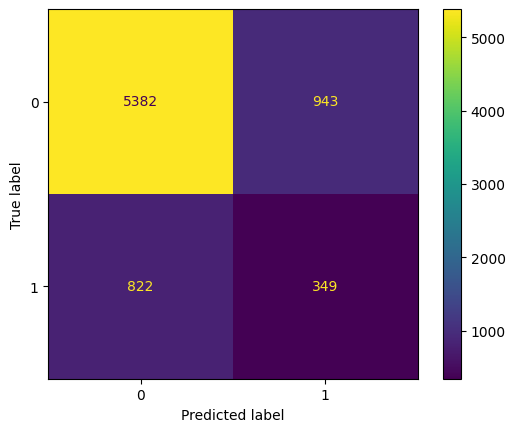

In [36]:
# Confusion matrix
cm = confusion_matrix(y_test_t.numpy(), y_pred.numpy())
tn, fp, fn, tp = cm.ravel()

# Custom credit / loan metrics
approval_rate = (fn + tn) / (tp + fp + tn + fn)
default_rate_approved = fn / (tn + fn) if (tn + fn) > 0 else 0
fnr = fn / (fn + tp) if (fn + tp) > 0 else 0

print(f"\nImportant loan metrics:")
print(f"Approval Rate: {approval_rate:.4f}")
print(f"Default Rate (Approved):{default_rate_approved:.4f}")
print(f"False Negative Rate: {fnr:.4f}")
print(f"Loss: {fn:.4f}")

# Display confusion matrix
cm_display = ConfusionMatrixDisplay(cm, display_labels=[0, 1])
cm_display.plot()
plt.show()